In [4]:
from langchain_openai import ChatOpenAI
import os
from pydantic import SecretStr

llm = ChatOpenAI(
    model="gpt-4o-mini",
    base_url="https://openrouter.ai/api/v1",
    api_key=SecretStr(os.environ["OPENROUTER_API_KEY"]),
    temperature=0,
)
llm

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0', 'langchain-openai': '1.6.0'}}, profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000002B47334A720>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002B473062BA0>, root_client=<openai.OpenAI object at 0x000002B472C89D00>

In [5]:
llm.invoke("Write a short poem about the beauty of nature.")

AIMessage(content="In whispered winds through ancient trees,  \nWhere sunlight dances, and shadows tease,  \nA symphony of colors bright,  \nIn every bloom, a pure delight.  \n\nThe mountains rise with majesty,  \nTheir peaks adorned in mystery,  \nWhile rivers sing a gentle tune,  \nReflecting dreams beneath the moon.  \n\nThe rustling leaves, the birds in flight,  \nNature's canvas, a wondrous sight,  \nIn every corner, life unfolds,  \nA timeless story, forever told.  ", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 102, 'prompt_tokens': 17, 'total_tokens': 119, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None, 'video_tokens': 0}, 'cost': 6.375e-05, 'is_byok': False, 'cost_

In [6]:
from typing import Annotated, TypedDict, List
from langgraph.graph import add_messages

class graph_schema(TypedDict):
    messages: Annotated[List, add_messages]

In [ ]:
def welcome(state:graph_schema) -> graph_schema:
    
    curr_messages=state["messages"]

    response = llm.invoke(curr_messages).content

    state["messages"] = f"Your message was {curr_messages}. Here is a response from the LLM: {response}"

    return state

In [8]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)
graph.add_node("welcome", welcome)

graph.add_edge(START, "welcome")
graph.add_edge("welcome", END)

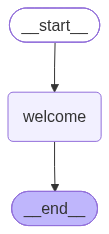

In [9]:
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import display


memory_saver = InMemorySaver()

memory_graph= graph.compile(checkpointer=memory_saver)

display(memory_graph)

In [11]:
response = memory_graph.invoke(
    {"messages":"Hello, I am a user of the LangGraph. Can you tell me more about it?"},
    {'configurable':{'thread_id': 'user1'}}
)

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

Hello, I am a user of the LangGraph. Can you tell me more about it?
================================ Human Message =================================

Your message was [HumanMessage(content='Hello, I am a user of the LangGraph. Can you tell me more about it?', additional_kwargs={}, response_metadata={}, id='0067ec64-789c-4855-92ed-8f022225a1e3')]. Here is a response from the LLM: LangGraph is a framework designed to facilitate the integration of natural language processing (NLP) with graph-based data structures. It allows users to leverage the strengths of both NLP and graph databases, enabling more sophisticated data analysis and retrieval methods. Here are some key features and concepts associated with LangGraph:

1. **Graph Representation**: LangGraph uses graph structures to represent relationships between entities, making it easier to model complex data and relationships.

2. **Natural Language Querie

In [12]:
response = memory_graph.invoke(
    {"messages":"What was my last message?"},
    {'configurable':{'thread_id': 'user1'}}
)

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

Hello, I am a user of the LangGraph. Can you tell me more about it?
================================ Human Message =================================

Your message was [HumanMessage(content='Hello, I am a user of the LangGraph. Can you tell me more about it?', additional_kwargs={}, response_metadata={}, id='0067ec64-789c-4855-92ed-8f022225a1e3')]. Here is a response from the LLM: LangGraph is a framework designed to facilitate the integration of natural language processing (NLP) with graph-based data structures. It allows users to leverage the strengths of both NLP and graph databases, enabling more sophisticated data analysis and retrieval methods. Here are some key features and concepts associated with LangGraph:

1. **Graph Representation**: LangGraph uses graph structures to represent relationships between entities, making it easier to model complex data and relationships.

2. **Natural Language Querie